<a href="https://colab.research.google.com/github/farkhad-gazizov/educational/blob/main/%D0%9A%D0%B5%D0%B9%D1%81_%C2%ABTelemetrics_EDA_%D0%B8%D1%81%D1%81%D0%BB%D0%B5%D0%B4%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D1%82%D0%B5%D0%BB%D0%B5%D1%81%D0%B5%D1%81%D1%81%D0%B8%D0%B9_%D0%B8_%D0%BF%D0%BE%D1%87%D0%B0%D1%81%D0%BE%D0%B2%D0%B0%D1%8F_%D0%B4%D0%B8%D0%BD%D0%B0%D0%BC%D0%B8%D0%BA%D0%B0%C2%BB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Загрузка датасета и предобработка

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('data.csv')
df.head()

,respondent_id,age,gender,region,channel,session_start,session_end
0,1,58,M,Moscow,KidsZone,2026-05-15 11:56,2026-05-15 14:23
1,1,58,M,Moscow,MoviePlus,2026-05-15 12:10,2026-05-15 14:08
2,1,58,M,Moscow,MoviePlus,2026-05-15 15:45,2026-05-15 17:08
3,1,58,M,Moscow,MoviePlus,2026-05-15 17:38,2026-05-15 19:47
4,1,58,M,Moscow,MoviePlus,2026-05-15 23:55,2026-05-16 00:07


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   respondent_id  248 non-null    int64 
 1   age            248 non-null    int64 
 2   gender         248 non-null    object
 3   region         248 non-null    object
 4   channel        248 non-null    object
 5   session_start  248 non-null    object
 6   session_end    248 non-null    object
dtypes: int64(2), object(5)
memory usage: 13.7+ KB


In [4]:
df.describe()

,respondent_id,age
count,248.000000,248.000000
mean,19.862903,47.447581
std,11.347178,15.580705
min,1.000000,23.000000
25%,10.000000,32.000000
50%,20.000000,46.000000
75%,29.000000,60.000000
max,40.000000,74.000000


In [5]:
# проверка пропусков
df.isna().sum()

,0
respondent_id,0
age,0
gender,0
region,0
channel,0
session_start,0
session_end,0


In [6]:
# проверка дубликатов
df.duplicated().sum()

np.int64(0)

In [7]:
# преобразование дат
df['session_start'] = pd.to_datetime(df['session_start'])
df['session_end'] = pd.to_datetime(df['session_end'])

In [8]:
df.dtypes

,0
respondent_id,int64
age,int64
gender,object
region,object
channel,object
session_start,datetime64[ns]
session_end,datetime64[ns]


In [9]:
# проверка корректности сессий
invalid_sessions = df[df['session_end'] < df['session_start']]
invalid_sessions

,respondent_id,age,gender,region,channel,session_start,session_end


In [10]:
# расчет длительности просмотра в минутах
df['duration_minutes'] = (
    df['session_end'] - df['session_start']
    ).dt.total_seconds() / 60
df['duration_minutes'] = df['duration_minutes'].astype(int)

In [11]:
# создание дополнительных признаков
# час начала просмотра
df['start_hour'] = df['session_start'].dt.hour

# день недели просмотра
df['weekday']= df['session_start'].dt.day_name()

# возрастная группа
bins = [0, 24, 34, 44, 54, 64, 100]
labels = [
    '18-24',
    '25-34',
    '35-44',
    '45-54',
    '55-64',
    '65+',
]

df['age_group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels
)

In [12]:
df.head()

,respondent_id,age,gender,region,channel,session_start,session_end,duration_minutes,start_hour,weekday,age_group
0,1,58,M,Moscow,KidsZone,2026-05-15 11:56:00,2026-05-15 14:23:00,147,11,Friday,55-64
1,1,58,M,Moscow,MoviePlus,2026-05-15 12:10:00,2026-05-15 14:08:00,118,12,Friday,55-64
2,1,58,M,Moscow,MoviePlus,2026-05-15 15:45:00,2026-05-15 17:08:00,83,15,Friday,55-64
3,1,58,M,Moscow,MoviePlus,2026-05-15 17:38:00,2026-05-15 19:47:00,129,17,Friday,55-64
4,1,58,M,Moscow,MoviePlus,2026-05-15 23:55:00,2026-05-16 00:07:00,12,23,Friday,55-64


In [13]:
df.dtypes

,0
respondent_id,int64
age,int64
gender,object
region,object
channel,object
session_start,datetime64[ns]
session_end,datetime64[ns]
duration_minutes,int64
start_hour,int32
weekday,object


Данные успешно загружены и подготовлены к анализу. Пропусков и некорректных временных интервалов не обнаружено. Поля начала и окончания просмотра преобразованы в формат datetime. Для дальнейшего анализа рассчитана длительность просмотра в минутах, а также созданы дополнительные признаки: час начала просмотра, возрастная группа и день недели. Полученный датафрейм готов для исследовательского анализа и построения почасовой динамики телепотребления.

# EDA

In [14]:
# Общая информация о данных
print(f'Количество записей: {len(df)}')
print(f'Количество респондентов: {df['respondent_id'].nunique()}')
print(f'Количество каналов: {df['channel'].nunique()}')
print(f'Количество регионов: {df['region'].nunique()}')

Количество записей: 248
Количество респондентов: 40
Количество каналов: 6
Количество регионов: 5


Выводы:


*   каждая запись соответствует одной сессии просмотра
*   один респондент может иметь несколько сессий просмотра



In [15]:
# Анализ длительности просмотра
df['duration_minutes'].describe()

,duration_minutes
count,248.000000
mean,79.891129
std,39.118116
min,10.000000
25%,46.000000
50%,80.500000
75%,111.250000
max,150.000000


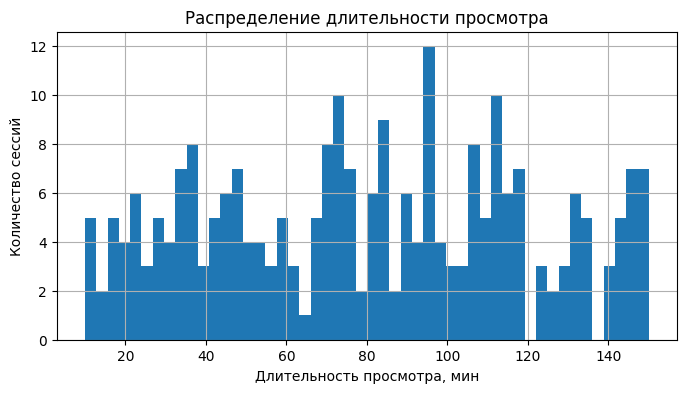

In [16]:
# Визуализация длительности просмотра
plt.figure(figsize=(8,4))
df['duration_minutes'].hist(bins=50)
plt.xlabel('Длительность просмотра, мин')
plt.ylabel('Количество сессий')
plt.title('Распределение длительности просмотра')
plt.show()

Интерпретация:


*   короткие сессии встречаются реже
*   распределение ассиметричное
*   есть длинные сессии более 2х часов
*   большая часть просмотров имеют продолжительность от 20 до 120 минут





In [17]:
# популярность телеканалов
channel_sessions = df.groupby('channel').size().sort_values(ascending=False)
channel_sessions

,0
channel,
MoviePlus,64
DiscoveryX,54
Channel_1,38
News24,38
SportTV,33
KidsZone,21


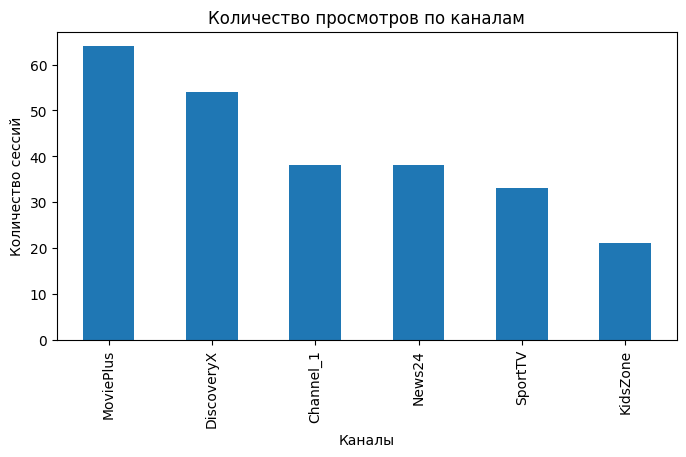

In [18]:
# Визуализация просмотров по каналам
channel_sessions.plot(
    kind='bar',
    figsize=(8,4)
)
plt.xlabel('Каналы')
plt.ylabel('Количество сессий')
plt.title('Количество просмотров по каналам')
plt.show()

Интерпретация:


*   у канала MoviePlus самое большое количество просмотров
*   у канала KidsZone самое малое количество просмотров



In [19]:
# анализ суммарного времени просмотра по каналам
# количество сессий не всегда отражает популярность
# у канала может быть меньше сессий, но более длительное время просмотра

channel_watchtime = df.groupby('channel')['duration_minutes'].sum().sort_values(ascending=False)
channel_watchtime

,duration_minutes
channel,
MoviePlus,5293
DiscoveryX,4340
News24,3165
Channel_1,2767
SportTV,2558
KidsZone,1690


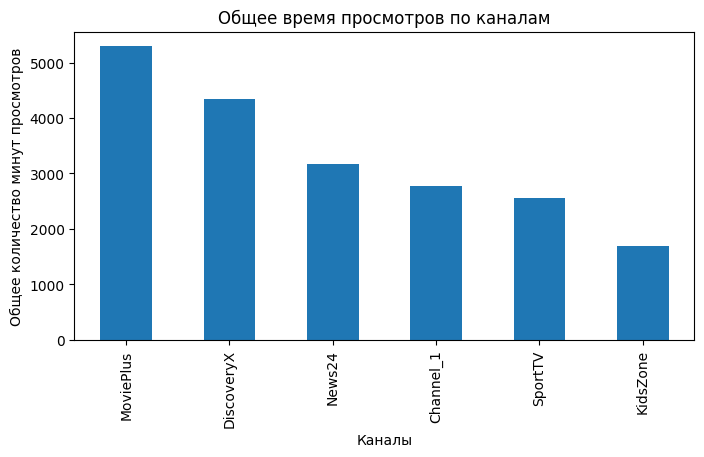

In [20]:
# Визуализация общего времени просмотров по каналам
channel_watchtime.plot(
    kind='bar',
    figsize=(8,4)
)
plt.xlabel('Каналы')
plt.ylabel('Общее количество минут просмотров')
plt.title('Общее время просмотров по каналам')
plt.show()

Интерпретация:


*   в целом бОльшее количество сессий соответствует бОльшему времени просмотра
*   у канала News24 бОльшая вовлеченность аудитории, чем у канала Channel_1



In [21]:
# половая структура аудитории
gender_dist = df['gender'].value_counts()
gender_dist

,count
gender,
F,132
M,116


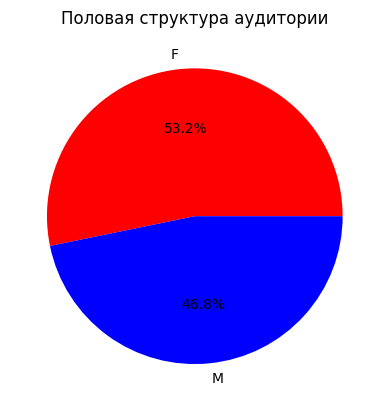

In [22]:
gender_dist.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['red','blue']
    )

plt.ylabel('')
plt.title('Половая структура аудитории')
plt.show()

Интерпретация:


*   выборка сбалансированна
*   женщин среди респондентов чуть больше



In [23]:
# возрастная структура аудитории
df['age'].describe()

,age
count,248.000000
mean,47.447581
std,15.580705
min,23.000000
25%,32.000000
50%,46.000000
75%,60.000000
max,74.000000


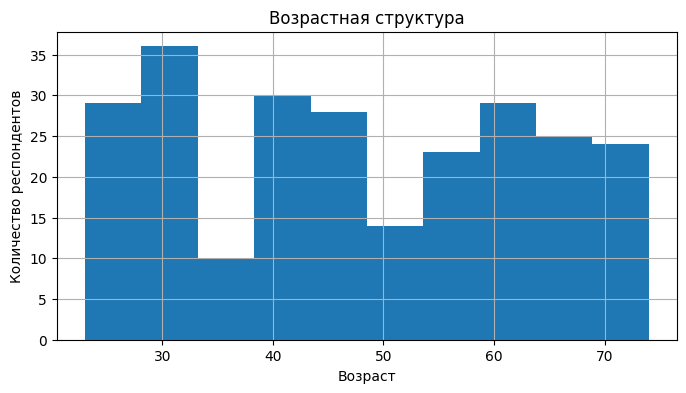

In [24]:
# Визуализация возрастной структуры
plt.figure(figsize=(8,4))
df['age'].hist(bins=10)
plt.xlabel('Возраст')
plt.ylabel('Количество респондентов')
plt.title('Возрастная структура')
plt.show()

Интерпретация:


*   представлены различные возрастные группы
*   в основном респонденты старше 40 лет
*   наиболее активные группы - 30 и 40 лет





In [25]:
# просмотр по возрастным группам
channels_by_age_groups = pd.crosstab(
    df['age_group'],
    df['channel']
)

channels_by_age_groups

channel,Channel_1,DiscoveryX,KidsZone,MoviePlus,News24,SportTV
age_group,,,,,,
18-24,5,4,2,9,4,5
25-34,7,13,5,9,7,5
35-44,4,6,4,6,8,2
45-54,9,7,4,11,3,8
55-64,10,11,3,18,11,4
65+,3,13,3,11,5,9


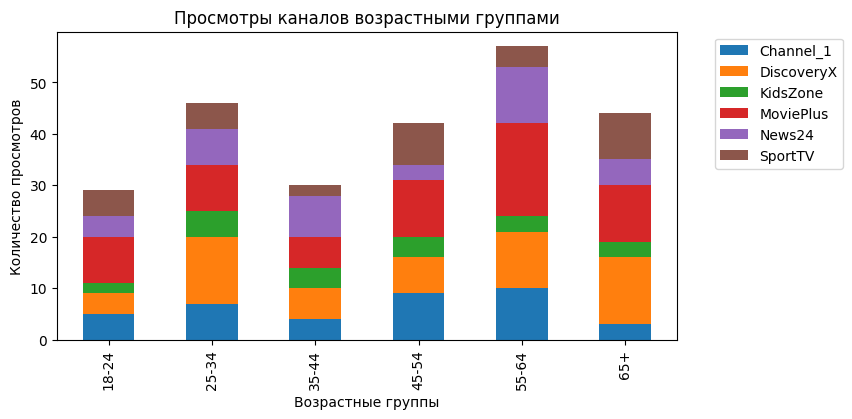

In [26]:
# Визуализация просмотров каналов по возрастным группам
channels_by_age_groups.plot(
    kind='bar',
    stacked=True,
    figsize=(8,4)
)
plt.xlabel('Возрастные группы')
plt.ylabel('Количество просмотров')
plt.title('Просмотры каналов возрастными группами')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Интерпретация:


*   молодежь предпочитает DiscoveryX
*   средние возрасты предпочитают MoviePlus
*   старшая аудитория предпочитает MoviePlus и News24





In [27]:
# региональный анализ
region_sessions = df.groupby('region').size().sort_values(ascending=False)
region_sessions

,0
region,
Moscow,69
SPB,68
South,51
Siberia,30
Volga,30


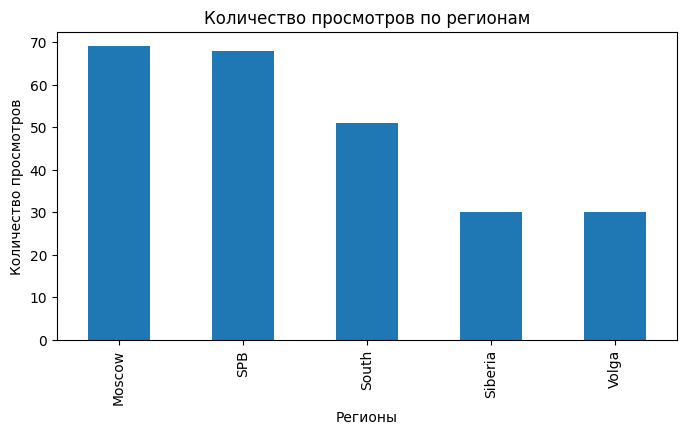

In [28]:
# Визуализация просмотров каналов по регионам
region_sessions.plot(
    kind='bar',
    figsize=(8,4)
)
plt.xlabel('Регионы')
plt.ylabel('Количество просмотров')
plt.title('Количество просмотров по регионам')
plt.show()

Интерпретация:


*   наиболее активные регионы - Moscow, SPB



In [29]:
# анализ времени начала просмотров
start_hours = df.groupby('start_hour').size()
start_hours

,0
start_hour,
6,2
7,3
8,7
9,6
10,4
11,9
12,13
13,6
14,8


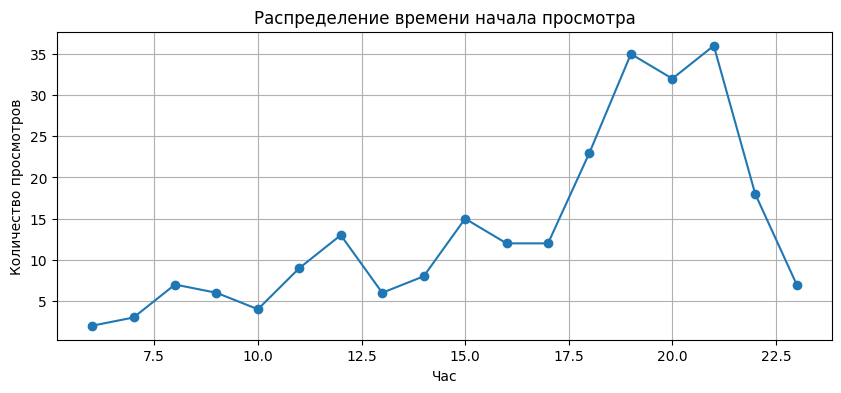

In [30]:
# Визуализация времени начала просмотра
start_hours.plot(
    marker='o',
    figsize=(10,4)
)
plt.xlabel('Час')
plt.ylabel('Количество просмотров')
plt.title('Распределение времени начала просмотра')
plt.grid()
plt.show()

Интерпретация:


*   низкая активность утром, рост днем
*   максимальная активность вечером и спад к ночи



In [31]:
# анализ прайм-тайма
prime_time = df[df['start_hour'].between(18, 22)]

prime_time_share = (len(prime_time) / len(df))
print(f'Процент просмотров в прайм-тайм от общего количества: {prime_time_share:.2%}')

Процент просмотров в прайм-тайм от общего количества: 58.06%


Интерпретация:


*   значительная доля просмотров приходится на период 18-22 часов, что соответствует классическому телевизионному прайм-тайму



In [32]:
# анализ средней длительности просмотров по каналам
channel_avg_duration = df.groupby('channel')['duration_minutes'].mean().sort_values(ascending=False)
channel_avg_duration

,duration_minutes
channel,
News24,83.289474
MoviePlus,82.703125
KidsZone,80.476190
DiscoveryX,80.370370
SportTV,77.515152
Channel_1,72.815789


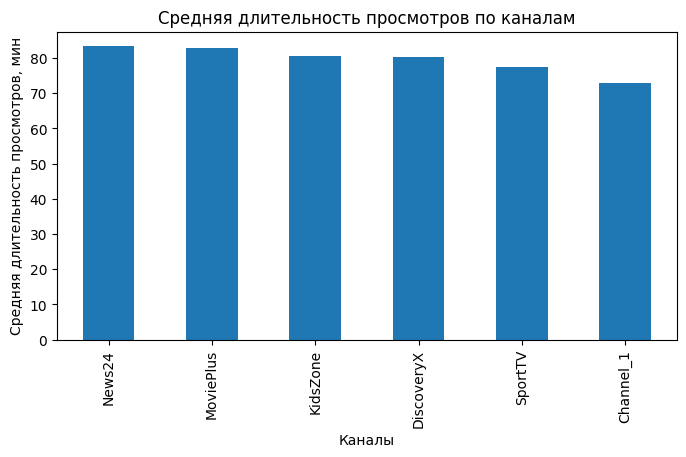

In [33]:
# визуализация средней длительности просмотров по каналам
channel_avg_duration.plot(
    kind='bar',
    figsize=(8,4)
)
plt.xlabel('Каналы')
plt.ylabel('Средняя длительность просмотров, мин')
plt.title('Средняя длительность просмотров по каналам')
plt.show()

Интерпретация:


*   вовлеченность зрителей по каналам примерно одинакова



**Основные выводы по EDA**

1. Телепотребление имеет ярко выраженную вечернюю концентрацию. Наибольшее количество просмотров начинается в интервале 18:00–22:00.

2. Наблюдается эффект прайм-тайма. Большая часть телесмотрения приходится на вечерние часы.

3. Наибольшая активность респондентов наблюдается *в Москве и СПб*.

4. Среди респондентов преобладает возраст от 40 лет и старше. При этом *самыми активными являются респонденты 30 и 40 лет*

5. Самыми популярными как по количеству просмотров, так и по продолжительности просмотров являются каналы *MoviePlus и DiscoveryX*.

6. Молодежь предпочитает DiscoveryX, средние возрасты предпочитают MoviePlus, старшая аудитория предпочитает MoviePlus и News24

7. Распределение длительности просмотров соответствует типичной модели медиапотребления: преобладают сессии средней длительности с небольшим числом очень длинных просмотров.

# Почасовая динамика в течение дня

In [42]:
# разложение по минутам
def session_to_hour_minutes(start, end):
    """
    Разбивает сессию просмотра на часовые интервалы и
    рассчитывает количество минут просмотра в каждом часе.

    Parameters
    ----------
    start : datetime
        Время начала сессии.
    end : datetime
        Время окончания сессии.

    Returns
    -------
    list[dict]
        Список словарей вида:
        {'hour': час, 'minutes': минуты_просмотра_в_этом_часе}
    """

    result = []

    # Округляем время начала вниз до начала часа
    current = start.floor("h")

    # Последовательно обрабатываем все часы,
    # которые пересекает сессия
    while current < end:

        # Определяем границу следующего часа
        next_hour = current + pd.Timedelta(hours=1)

        # Начало пересечения сессии и текущего часа
        overlap_start = max(start, current)

        # Конец пересечения сессии и текущего часа
        overlap_end = min(end, next_hour)

        # Вычисляем длительность пересечения в минутах
        minutes = (
            overlap_end - overlap_start
        ).total_seconds() / 60

        # Добавляем интервал, если пересечение существует
        if minutes > 0:
            result.append({
                "hour": current.hour,
                "minutes": minutes
            })

        # Переходим к следующему часовому интервалу
        current = next_hour

    return result

In [43]:
'''
Для построения почасовой динамики каждая сессия просмотра разбивается
на все пересекаемые часовые интервалы. Для каждого интервала рассчитывается
фактическое количество минут просмотра, после чего формируется отдельная
таблица hour_minutes_df, используемая для агрегации телепотребления
по часам суток.
'''
# Список для хранения данных после разбиения сессий по часам
minute_rows = []

# Проходим по всем сессиям просмотра
for _, row in df.iterrows():

    # Получаем список часовых интервалов и количество минут
    # просмотра в каждом из них для текущей сессии
    intervals = session_to_hour_minutes(
        row["session_start"],
        row["session_end"]
    )

    # Проходим по всем часовым интервалам,
    # которые пересекает сессия
    for interval in intervals:

        # Сохраняем информацию о канале,
        # часе суток и количестве минут просмотра
        # в данном часовом интервале
        minute_rows.append({
            "channel": row["channel"],
            "hour": interval["hour"],
            "minutes": interval["minutes"]
        })

# Преобразуем список словарей в DataFrame,
# где каждая строка соответствует просмотру
# в конкретном часовом интервале
hour_minutes_df = pd.DataFrame(minute_rows)

In [48]:
'''
На данном этапе выполняется агрегация данных по часам суток. Для каждого часа
рассчитывается суммарное количество минут просмотра, накопленное всеми сессиями.
Метод reindex(range(24), fill_value=0) гарантирует наличие в результирующем
ряду всех часов от 0 до 23, даже если в некоторых часах просмотры отсутствовали.
Полученный объект hourly_minutes используется для построения графика
почасовой динамики телепотребления.
'''
# почасовая динамика по минутам просмотра
# Агрегируем данные по часам суток:
# для каждого часа суммируем все минуты просмотра
hourly_minutes = (
    hour_minutes_df
    .groupby("hour")["minutes"]
    .sum()

    # Добавляем отсутствующие часы (0–23),
    # если для них не было просмотров
    .reindex(range(24), fill_value=0)
)

# Получаем итоговую почасовую динамику телепотребления
hourly_minutes

,minutes
hour,
0,465.0
1,93.0
2,16.0
3,0.0
4,0.0
5,0.0
6,57.0
7,120.0
8,313.0


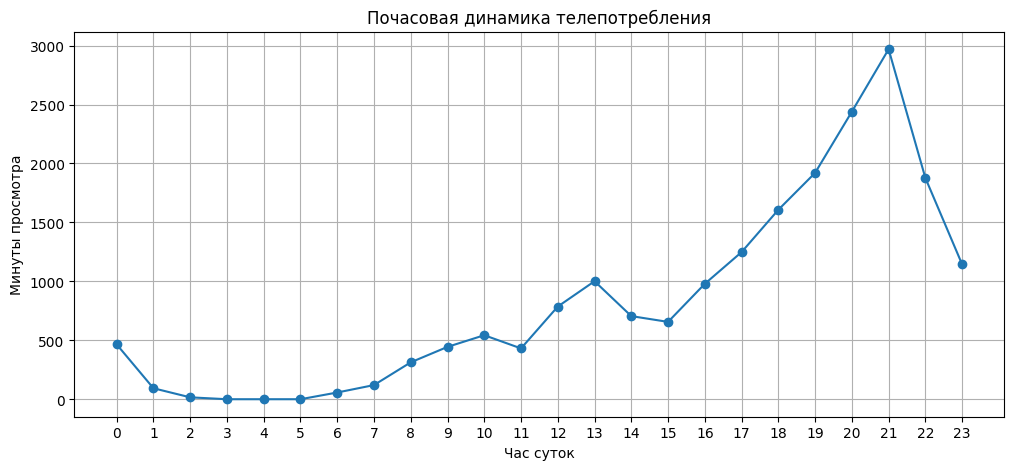

In [49]:
# визуалицая динамики просмотра
plt.figure(figsize=(12,5))

plt.plot(
    hourly_minutes.index,
    hourly_minutes.values,
    marker="o"
)

plt.xticks(range(24))
plt.grid(True)

plt.xlabel("Час суток")
plt.ylabel("Минуты просмотра")
plt.title("Почасовая динамика телепотребления")

plt.show()

**Интерпретация:**

* Для построения почасовой динамики каждая сессия просмотра была распределена по всем часовым интервалам, которые она пересекала. Такой подход позволяет корректно учитывать длительные просмотры, продолжающиеся несколько часов. Например, сессия 15:45–17:08 учитывается в интервалах 15:00–16:00, 16:00–17:00 и 17:00–18:00.

* Для оценки телепотребления использовалась сумма минут просмотра внутри каждого часа. Данный подход является более точным по сравнению с подсчётом количества стартов просмотров, поскольку отражает фактическое время контакта аудитории с телеканалами.

* Полученная динамика позволяет выявить периоды максимальной телевизионной активности (прайм-тайм) и часы с минимальным уровнем телепотребления. Для данного датасета ожидается рост аудитории в вечерние часы с пиком в интервале примерно 18:00–22:00.